In [1]:
import os
import numpy as np
import pandas as pd

from scipy.stats import ranksums, ttest_ind, mannwhitneyu

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='ticks', context='talk')
import textalloc as ta

from tqdm import tqdm

In [2]:
India_beta = pd.read_csv('/broad/smillie-data/proj/CDSA/epigenetics/India_site/epic2_beta.csv', index_col=0)
India_beta.reset_index(inplace=True)
India_beta.rename(columns={'index': 'CpG_ID_v2'}, inplace=True)
print(India_beta.shape)

US_beta2 = pd.read_csv('/broad/smillie-data/proj/CDSA/epigenetics/US_site/epic2_beta.csv', index_col=0)
US_beta2.reset_index(inplace=True)
US_beta2.rename(columns={'index': 'CpG_ID_v2'}, inplace=True)
print(US_beta2.shape)

US_beta1 = pd.read_csv('/broad/smillie-data/proj/CDSA/epigenetics/US_site/epic_beta.csv', index_col=0)
US_beta1.reset_index(inplace=True)
US_beta1.rename(columns={'index': 'CpG_ID'}, inplace=True)
print(US_beta1.shape)

(936990, 190)
(936990, 60)
(866836, 106)


In [4]:
India_beta

,CpG_ID_v2,207222490101_R01C01,207222490101_R02C01,207222490101_R03C01,207222490101_R04C01,207222490101_R05C01,207222490101_R06C01,207222490101_R07C01,207222490101_R08C01,207222490110_R01C01,...,208369620009_R06C01,208369620009_R07C01,208369620009_R08C01,208369630015_R01C01,208369630015_R02C01,208369630015_R03C01,208369630015_R04C01,208369630015_R05C01,208369630015_R06C01,208369630015_R07C01
0,cg25324105_BC11,0.087314,0.110821,0.087703,0.057049,0.030411,0.033294,0.031851,0.072985,0.096857,...,0.025289,0.043530,0.094040,0.081112,0.143967,0.040853,0.054831,0.036111,0.044514,0.157508
1,cg25383568_TC11,0.844464,0.863642,0.877561,0.921367,0.823411,0.904870,0.856918,0.903771,0.809932,...,0.897445,0.896684,0.927415,0.811783,0.794825,0.842816,0.877624,0.919089,0.955000,0.807611
2,cg25455143_BC11,0.023093,0.015931,0.017222,0.017762,0.016043,0.015561,0.016677,0.013074,0.016650,...,0.018338,0.014109,0.019916,0.014592,0.015202,0.016458,0.016534,0.017567,0.014861,0.012669
3,cg25459778_BC11,0.014466,0.013168,0.012346,0.011877,0.012278,0.012035,0.011227,0.011023,0.013302,...,0.012047,0.009663,0.012219,0.011677,0.011579,0.014052,0.014720,0.012712,0.011511,0.010445
4,cg25487775_BC11,0.524608,0.646530,0.656608,0.508256,0.628597,0.549051,0.529025,0.790971,0.586487,...,0.521298,0.718476,0.415325,0.679670,0.690007,0.595238,0.640598,0.607985,0.472193,0.736227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
936985,ch.14.1558261F_BO21,0.051466,0.050752,0.061507,0.067690,0.057984,0.063353,0.077414,0.085060,0.091708,...,0.068377,0.077208,0.069241,0.063612,0.066346,0.044770,0.043680,0.038863,0.059183,0.063976
936986,ch.X.79027977R_BC21,0.033563,0.031066,0.024320,0.038935,0.033432,0.031048,0.036267,0.036637,0.032121,...,0.040381,0.042048,0.047170,0.028072,0.042165,0.034939,0.032586,0.027479,0.026788,0.024991
936987,ch.1.79281177F_BO21,0.043253,0.054693,0.063576,0.076382,0.057965,0.063961,0.066797,0.060216,0.069812,...,0.057365,0.066467,0.049727,0.061155,0.061614,0.056243,0.058598,0.054273,0.054679,0.049624
936988,ch.12.78471492F_BC21,0.044262,0.050486,0.054593,0.045389,0.051231,0.055486,0.053940,0.053948,0.068019,...,0.044779,0.040896,0.050867,0.046625,0.048415,0.044161,0.042655,0.034258,0.039745,0.034200


In [3]:
all_methylation = India_beta.merge(US_beta2, how='outer', on='CpG_ID_v2')

In [4]:
all_methylation.insert(1, 'CpG_ID', all_methylation.CpG_ID_v2.apply(lambda x: x.split('_BC')[0].split('_TC')[0]))

In [5]:
all_methylation = all_methylation.merge(US_beta1, how='outer', on='CpG_ID')

In [6]:
all_methylation

,CpG_ID_v2,CpG_ID,207222490101_R01C01,207222490101_R02C01,207222490101_R03C01,207222490101_R04C01,207222490101_R05C01,207222490101_R06C01,207222490101_R07C01,207222490101_R08C01,...,207558890069_R08C01,207558890089_R01C01,207558890089_R02C01,207558890089_R03C01,207558890089_R05C01,207558890089_R07C01,207558890089_R08C01,207558890100_R01C01,207558890100_R02C01,207558890100_R06C01
0,cg00000029_TC21,cg00000029,0.547656,0.474492,0.488389,0.533307,0.617959,0.512475,0.621685,0.541746,...,0.612628,0.554484,0.572276,0.616650,0.647291,0.683392,0.354393,0.548607,0.582931,0.605112
1,NaN,cg00000103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.884704,0.845526,0.850873,0.856312,0.880170,0.865784,0.859271,0.879901,0.895328,0.896994
2,cg00000109_TC21,cg00000109,0.900345,0.918598,0.908301,0.905783,0.916358,0.920341,0.871853,0.929426,...,0.888419,0.895540,0.887231,0.892838,0.905982,0.882454,0.880403,0.900019,0.919769,0.908151
3,cg00000155_BC21,cg00000155,0.943248,0.951223,0.943262,0.948652,0.926590,0.945183,0.941234,0.931499,...,0.943438,0.917306,0.929124,0.928527,0.936153,0.919877,0.924857,0.939696,0.936356,0.942947
4,cg00000158_BC21,cg00000158,0.954627,0.952825,0.953606,0.952670,0.949572,0.958047,0.964161,0.954457,...,0.938866,0.943675,0.942413,0.939472,0.943408,0.952759,0.944916,0.949035,0.947657,0.949819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1081210,nv-GRCh38-chr9-77794572-77794572-T-C_BC11,nv-GRCh38-chr9-77794572-77794572-T-C,0.052773,0.067877,0.045616,0.019353,0.025592,0.029488,0.031365,0.054682,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1081211,nv-GRCh38-chr9-77797577-77797577-C-A_BC11,nv-GRCh38-chr9-77797577-77797577-C-A,0.221387,0.193082,0.213418,0.223404,0.277148,0.162337,0.214104,0.181902,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1081212,nv-GRCh38-chr9-77797577-77797577-C-T_BC11,nv-GRCh38-chr9-77797577-77797577-C-T,0.417820,0.397607,0.465018,0.431362,0.461314,0.475256,0.389108,0.440466,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1081213,nv-GRCh38-chr9-77922339-77922339-C-A_TC21,nv-GRCh38-chr9-77922339-77922339-C-A,0.928473,0.947028,0.940981,0.932237,0.936941,0.949459,0.954060,0.940755,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
us_manifest = pd.read_csv('/broad/smillie-data/proj/CDSA/epigenetics/US_site/CDSA_epigenetics_manifest.csv')
us_manifest

,PDO,Batch,Chip Well Barcode,Stock Sample ID,Collaborator Sample ID,Grn.idat,Red.idat,Delivery Date
0,PDO-26048,B1,205555380005_R03C01,SM-LHJSL,PRISM_10208,205555380005_R03C01_Grn.idat,205555380005_R03C01_Red.idat,"Aug 14, 2023, 3:38:02 PM"
1,PDO-26048,B1,205555380005_R04C01,SM-LJDR8,PRISM_8971,205555380005_R04C01_Grn.idat,205555380005_R04C01_Red.idat,"Aug 14, 2023, 3:37:03 PM"
2,PDO-26048,B1,205555380005_R05C01,SM-LJDS5,PRISM_9423,205555380005_R05C01_Grn.idat,205555380005_R05C01_Red.idat,"Aug 14, 2023, 3:37:13 PM"
3,PDO-26048,B1,205555380005_R06C01,SM-LJDSV,PRISM_9753,205555380005_R06C01_Grn.idat,205555380005_R06C01_Red.idat,"Aug 14, 2023, 3:37:14 PM"
4,PDO-26048,B1,205555380005_R07C01,SM-LHJQN,PRISM_9878,205555380005_R07C01_Grn.idat,205555380005_R07C01_Red.idat,"Aug 14, 2023, 3:37:16 PM"
...,...,...,...,...,...,...,...,...
439,PDO-35526,B4,208186540022_R04C01,SM-NPJZU,27525,208186540022_R04C01_Grn.idat,208186540022_R04C01_Red.idat,"Jun 26, 2024, 12:00:00 AM"
440,PDO-35526,B4,208214460020_R01C01,SM-NPJYS,1167898,208214460020_R01C01_Grn.idat,208214460020_R01C01_Red.idat,"Jun 26, 2024, 12:00:00 AM"
441,PDO-35526,B4,208186540022_R01C01,SM-NPJYT,1168158,208186540022_R01C01_Grn.idat,208186540022_R01C01_Red.idat,"Jun 26, 2024, 12:00:00 AM"
442,PDO-35526,B4,208222460046_R06C01,SM-NPK1E,27610,208222460046_R06C01_Grn.idat,208222460046_R06C01_Red.idat,"Jun 26, 2024, 12:00:00 AM"


In [7]:
### EPI sample names mapping to MGX sample names

##### US #####
us_metadata  = pd.read_csv('/broad/smillie-data/proj/CDSA/metadata/CDSA_US_20250520.csv', header=1)
us_metadata  = us_metadata[us_metadata['fastq file name(R1)'].apply(lambda x: 'fastq.gz' in x if type(x)==str else False)].reset_index(drop=True)
us_metadata  = us_metadata[(us_metadata['Epigenetic Sample Label'].notnull()) & (us_metadata['Epigenetic Sample Label'].str.isnumeric())].reset_index(drop=True)
us_sampleID2mgxSampleName = dict(zip(us_metadata['Epigenetic Sample Label'], 
                                     us_metadata['fastq file name(R1)'].apply(lambda x: x.split('_1.fastq')[0].split('_2.fastq')[0].split('_R1_001.fastq.gz')[0])))

us_manifest = pd.read_csv('/broad/smillie-data/proj/CDSA/epigenetics/US_site/CDSA_epigenetics_manifest.csv')
us_epiID2sampleID = dict(zip(us_manifest['Chip Well Barcode'], us_manifest['Collaborator Sample ID']))
us_epiID2sampleID = {key:val for key, val in us_epiID2sampleID.items() if val in set(us_metadata['Epigenetic Sample Label'])}
us_epiID2mgxSampleName = {key: us_sampleID2mgxSampleName[val] for key, val in us_epiID2sampleID.items() if val in us_sampleID2mgxSampleName}
print(len(us_epiID2mgxSampleName))

us_epi_samples = [fname.split('_Grn.idat')[0].split('_Red.idat')[0] for fname in os.listdir('/broad/smillie-data/proj/CDSA/epigenetics/US_site/idats/epic_v1')]
us_epi_samples = us_epi_samples + [elem.split('_Grn.idat')[0].split('_Red.idat')[0] for elem in os.listdir('/broad/smillie-data/proj/CDSA/epigenetics/US_site/idats/epic_v2')]
us_epi_samples = set(us_epi_samples)
assert us_epi_samples == set(us_epiID2mgxSampleName.keys())


##### India #####
India_epi2sample = pd.read_csv('/broad/smillie-data/proj/CDSA/epigenetics/India_site/manifest_subject2epi.csv')
India_epi2sample = dict(zip(India_epi2sample['epi_sampleID'], India_epi2sample['Sample Name']))
india_epi_samples = set([fname.split('_Grn.idat')[0].split('_Red.idat')[0] for fname in os.listdir('/broad/smillie-data/proj/CDSA/epigenetics/India_site/idats')])
assert india_epi_samples == set(India_epi2sample.keys())
print(len(India_epi2sample))

##### MERGE #####
CDSA_epiID2mgxSampleName = {**us_epiID2mgxSampleName, **India_epi2sample}
len(CDSA_epiID2mgxSampleName)

# np.savetxt('/broad/smillie-data/proj/CDSA/epigenetics/epiSampleID_2_subjectID.txt', np.array(list(CDSA_epiID2mgxSampleName.items())), fmt='%s\t%s')

164
189


353

In [13]:
v1_epi_samples = np.array(list(set([fname.split('_Grn.idat')[0].split('_Red.idat')[0] for fname in os.listdir('/broad/smillie-data/proj/CDSA/epigenetics/US_site/idats/epic_v1')])))
v1_samples = np.array([CDSA_epiID2mgxSampleName[elem] for elem in v1_epi_samples])

In [9]:
all_methylation.columns = list(all_methylation.columns[:2]) + list(all_methylation.columns[2:].map(CDSA_epiID2mgxSampleName))

In [10]:
all_methylation

,CpG_ID_v2,CpG_ID,PD048,PD049,PD050,PD051,PD052,PD053,PD054,PD055,...,HGFW3DSXC_1_SM-OGWJ6_S36_L001,PSA1124769,PSC_1159043,PSC_1159038,PSC_1158597,HGFW3DSXC_1_SM-OGWHM_S45_L001,PSC_1159046,PSC_1158606,PSC_1159035,HGFW3DSXC_1_SM-OGWH8_S39_L001
0,cg00000029_TC21,cg00000029,0.547656,0.474492,0.488389,0.533307,0.617959,0.512475,0.621685,0.541746,...,0.612628,0.554484,0.572276,0.616650,0.647291,0.683392,0.354393,0.548607,0.582931,0.605112
1,NaN,cg00000103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.884704,0.845526,0.850873,0.856312,0.880170,0.865784,0.859271,0.879901,0.895328,0.896994
2,cg00000109_TC21,cg00000109,0.900345,0.918598,0.908301,0.905783,0.916358,0.920341,0.871853,0.929426,...,0.888419,0.895540,0.887231,0.892838,0.905982,0.882454,0.880403,0.900019,0.919769,0.908151
3,cg00000155_BC21,cg00000155,0.943248,0.951223,0.943262,0.948652,0.926590,0.945183,0.941234,0.931499,...,0.943438,0.917306,0.929124,0.928527,0.936153,0.919877,0.924857,0.939696,0.936356,0.942947
4,cg00000158_BC21,cg00000158,0.954627,0.952825,0.953606,0.952670,0.949572,0.958047,0.964161,0.954457,...,0.938866,0.943675,0.942413,0.939472,0.943408,0.952759,0.944916,0.949035,0.947657,0.949819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1081210,nv-GRCh38-chr9-77794572-77794572-T-C_BC11,nv-GRCh38-chr9-77794572-77794572-T-C,0.052773,0.067877,0.045616,0.019353,0.025592,0.029488,0.031365,0.054682,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1081211,nv-GRCh38-chr9-77797577-77797577-C-A_BC11,nv-GRCh38-chr9-77797577-77797577-C-A,0.221387,0.193082,0.213418,0.223404,0.277148,0.162337,0.214104,0.181902,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1081212,nv-GRCh38-chr9-77797577-77797577-C-T_BC11,nv-GRCh38-chr9-77797577-77797577-C-T,0.417820,0.397607,0.465018,0.431362,0.461314,0.475256,0.389108,0.440466,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1081213,nv-GRCh38-chr9-77922339-77922339-C-A_TC21,nv-GRCh38-chr9-77922339-77922339-C-A,0.928473,0.947028,0.940981,0.932237,0.936941,0.949459,0.954060,0.940755,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# all_methylation.to_csv('/broad/smillie-data/proj/CDSA/epigenetics/CDSA_methylation_table.csv', index=False)
all_methylation = pd.read_csv('/broad/smillie-data/proj/CDSA/epigenetics/CDSA_methylation_table.csv')

In [11]:
CDSA_meta = pd.read_csv('/broad/smillie-data/proj/CDSA/metadata/CDSA_Dhakan_cohort_metadata.csv')
sampleID2IBD = dict(zip(CDSA_meta['sampleID'], CDSA_meta['dx']!='HC'))
sampleID2country = dict(zip(CDSA_meta['sampleID'], CDSA_meta['cohort'].map({'CDSA-US': 'US', 'CDSA-India': 'India', 'DhakanHC': 'India'})))

In [14]:
all_methylation_v2 = all_methylation[all_methylation.columns[~all_methylation.columns.isin(v1_samples)]].copy()
all_methylation_v2.drop(columns=['CpG_ID'], inplace=True)
all_methylation_v2.drop_duplicates(inplace=True)
all_methylation_v2.dropna(subset = ['CpG_ID_v2'], inplace=True)
all_methylation_v2.set_index('CpG_ID_v2', inplace=True)

In [25]:
CDSA_meta = pd.read_csv('/broad/smillie-data/proj/CDSA/metadata/CDSA_Dhakan_cohort_metadata.csv')
CDSA_meta = CDSA_meta[CDSA_meta.cohort != 'DhakanHC'].copy()
CDSA_meta['bornInUS'] = [False if elem==1 else True if elem>1 else np.nan for elem in CDSA_meta.immigration_gen]
CDSA_meta = CDSA_meta[['sampleID', 'dx' ,'age', 'bmi', 'sex', 'age_immigration', 'bornInUS', 'age_dx', 'Acculturation_scroe', 'IBD']].copy()
CDSA_meta['bmi'] = pd.to_numeric(CDSA_meta['bmi'], errors='coerce')
CDSA_meta.to_csv('/broad/smillie-data/proj/CDSA/epigenetics/CDSA_metadata.csv', index=False)

In [16]:
to_test_mat = all_methylation_v2[[col for col in all_methylation_v2.columns if col[:2] in ('PD', 'HD')]].copy()
to_test_mat.shape

(936990, 189)

In [27]:
IBD_vec = np.array([sampleID2IBD[elem] for elem in to_test_mat])
country_vec = np.array([sampleID2country[elem] for elem in to_test_mat])
# is_v2_vec = np.array([col not in v1_samples for col in all_methylation_v2.columns[1:]])

print(IBD_vec.shape, country_vec.shape)

(189,) (189,)


In [20]:
maxmin = np.nanmax(to_test_mat, axis=1) - np.nanmin(to_test_mat, axis=1)
p5p95 = np.nanpercentile(to_test_mat, [5, 95], axis=1)
p95p5 = p5p95[1] - p5p95[0]

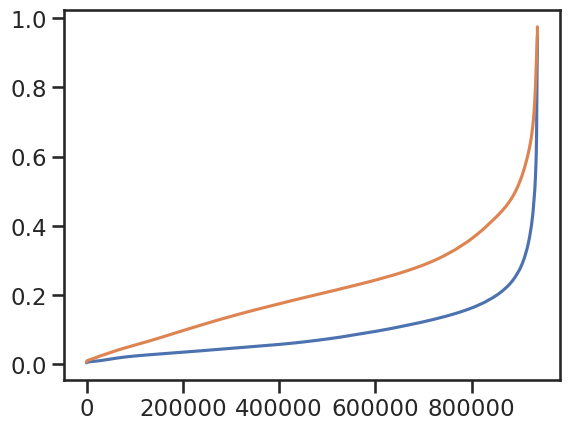

In [21]:
plt.plot(sorted(p95p5))
plt.plot(sorted(maxmin));

In [24]:
i_to_test = (p95p5) > 0.2
i_to_test.sum()

83665

In [61]:
i = 500000
to_test_mat.index[i]

'cg14298269_BC11'

In [62]:
res = []
sites_list = np.array(to_test_mat.index)
for i in tqdm(np.arange(i_to_test.shape[0])[i_to_test], ncols=100):
    row = to_test_mat.iloc[i].values
    IBD_epi = row[IBD_vec]
    IBD_epi = IBD_epi[~np.isnan(IBD_epi)]
    HC_epi = row[~IBD_vec]
    HC_epi = HC_epi[~np.isnan(HC_epi)]
    IBD_coef, IBD_pval = ranksums(IBD_epi, HC_epi)
    res.append({'tested_index': i, 'epi_site' : sites_list[i], 'IBD_pval': IBD_pval, 'IBD_coef' : IBD_coef})
res = pd.DataFrame(res)

100%|███████████████████████████████████████████████████████| 83665/83665 [00:40<00:00, 2045.40it/s]


In [64]:
res.set_index('epi_site', inplace=True)

In [65]:
res

,tested_index,IBD_pval,IBD_coef
epi_site,,,
cg00000776_TC21,20,7.713145e-02,1.767578
cg00001476_TC21,39,6.016787e-01,-0.521988
cg00002033_TC11,66,6.249508e-01,-0.488846
cg00002033_TC12,67,6.545731e-01,-0.447418
cg00002190_TC21,75,8.079729e-01,-0.243042
...,...,...,...
nv-GRCh38-chr7-140753348-140753348-C-A_BC11,936935,1.224550e-02,2.504990
nv-GRCh38-chr7-152265113-152265113-C-A_BC11,936950,1.380456e-01,1.483109
nv-GRCh38-chr7-55174015-55174015-G-A_TO11,936964,3.134199e-01,-1.008072


In [66]:
sig_res = res[res.IBD_pval < 0.05/len(res)].copy()
sig_res.shape

(453, 3)

In [67]:
sig_res

,tested_index,IBD_pval,IBD_coef
epi_site,,,
cg00061629_TC21,2358,6.636799e-09,5.799866
cg00090782_BC21,3431,2.619880e-08,-5.565109
cg00097436_BC21,3709,4.514309e-07,5.045883
cg00099742_BC21,3796,1.929163e-15,7.945816
cg00163611_TC21,6080,2.828743e-13,7.302307
...,...,...,...
nv-GRCh38-chr3-10149805-10149805-G-A_BC11,936789,8.677242e-08,-5.352448
nv-GRCh38-chr3-10149886-10149886-T-C_BC11,936797,5.910310e-08,5.421494
nv-GRCh38-chr4-152328349-152328349-G-C_TC11,936893,1.287336e-07,5.280640


In [3]:
v2_annot_df = pd.read_csv('/broad/smillie-data/proj/CDSA/epigenetics/EPICv2_annotation_table.csv', index_col=0)

/local/scratch/52403343.1.interactive/ipykernel_47367/1059098458.py:1: DtypeWarning: Columns (8,10,11,20,39,40,42) have mixed types. Specify dtype option on import or set low_memory=False.
  v2_annot_df = pd.read_csv('/broad/smillie-data/proj/CDSA/epigenetics/EPICv2_annotation_table.csv', index_col=0)


In [4]:
v2_annot_df.head()

,chr,pos,strand,Name,AddressA,AddressB,ProbeSeqA,ProbeSeqB,Type,NextBase,...,GencodeV41_Accession,Phantom5_Enhancers,HMM_Island,Regulatory_Feature_Group,Methyl450_Enhancer,DMR,Methyl450_Loci,Methyl27_Loci,EPICv1_Loci,Manifest_probe_match
cg25324105_BC11,chr19,37692358,+,cg25324105_BC11,1754126,99753217.0,ATTTATAAACTAATAACCCAAAATACATTTCCCAAAAACCTTCACA...,GTTTATAAACTAATAACCCGAAATACATTTCCCAAAAACCTTCGCG...,I,A,...,ENST00000587199.5;ENST00000589676.5;ENST000005...,NaN,NaN,Unclassified_Cell_type_specific,True,DMR,cg25324105,NaN,cg25324105,True
cg25383568_TC11,chr19,38727081,-,cg25383568_TC11,79792482,69667133.0,AAACCAAAAAAATAACAAACTACTCACCTTATCAAAATAATTAAAA...,AAACCGAAAAAATAACAAACTACTCACCTTATCGAAATAATTAAAA...,I,C,...,ENST00000252699.7;ENST00000424234.7;ENST000004...,NaN,NaN,Gene_Associated_Cell_type_specific,True,NaN,cg25383568,NaN,cg25383568,True
cg25455143_BC11,chr19,1591515,-,cg25455143_BC11,80699190,7659147.0,ATAAAAAAAAATATACAACTAATCCCCCTTTTTCCCACAACTCAAA...,ATAAAAAAAAATATACGACTAATCCCCCTTTTTCCCACAACTCGAA...,I,T,...,NaN,NaN,NaN,NaN,False,NaN,cg25455143,NaN,cg25455143,True
cg25459778_BC11,chr16,1614581,+,cg25459778_BC11,60797262,65710482.0,AAAAATTTAAAACAAACAACAACAACCATATTAAAAACACATCAAA...,AAAAATTTAAAACAAACAACGACGACCATATTAAAAACGCGTCGAA...,I,C,...,ENST00000293925.9,NaN,NaN,NaN,False,NaN,cg25459778,cg25459778,cg25459778,True
cg25487775_BC11,chr2,161237458,+,cg25487775_BC11,5799427,89606481.0,AAAAACAACCTAAAAAACAACCCCCTACCCTACTCTACAAAAAAAA...,AAAAACAACCTAAAAAACAACCCCCTACCCTACTCTACAAAAAAAA...,I,A,...,NaN,NaN,NaN,NaN,False,NaN,cg25487775,NaN,cg25487775,True


In [86]:
res = res.merge(v2_annot_df[['chr', 'pos', 'Islands_Name', 'Relation_to_Island', 
                           'UCSC_RefGene_Group', 'UCSC_RefGene_Name', 'UCSC_RefGene_Accession', 
                           'GencodeV41_Group', 'GencodeV41_Name', 'GencodeV41_Accession']], how='left', left_index=True, right_index=True)

In [75]:
sig_res[sig_res.UCSC_RefGene_Name.notnull()]

,tested_index,IBD_pval,IBD_coef,chr,pos,Islands_Name,Relation_to_Island,UCSC_RefGene_Group,UCSC_RefGene_Name,UCSC_RefGene_Accession,GencodeV41_Group,GencodeV41_Name,GencodeV41_Accession
epi_site,,,,,,,,,,,,,
cg00090782_BC21,3431,2.619880e-08,-5.565109,chr10,42753422.0,chr10:42753075-42755464,Island,exon_1,LOC283028,NR_136644.1,exon_1,ENSG00000259869,ENST00000568976.2
cg00218840_TC21,8086,5.734120e-10,6.197571,chr1,228651596.0,chr1:228646195-228648421;chr1:228650239-228650457,Shore,exon_2,DUSP5P1,NR_002834.1_2,TSS1500,ENSG00000206878.1,ENST00000384151.1
cg00221525_TC21,8191,3.905610e-07,5.073502,chr16,31074258.0,chr16:31073022-31073743;chr16:31074203-31074727,Island,TSS200;TSS1500;TSS200,ZNF646;ZNF668;ZNF668,NM_014699.4;NM_001172668.2;NM_024706.5,TSS200;TSS1500;TSS1500;TSS1500;TSS1500;TSS200;...,ENSG00000167394.13;ENSG00000167394.13;ENSG0000...,ENST00000300849.5;ENST00000538906.5;ENST000003...
cg00266865_TC11,9893,7.822113e-09,5.772247,chr22,29581960.0,chr22:29580951-29581227,Shore,TSS1500;TSS1500,NIPSNAP1;NIPSNAP1,NM_003634.4;NM_001202502.2,TSS1500;TSS1500;TSS1500;TSS1500;TSS1500;TSS1500,ENSG00000184117.12;ENSG00000184117.12;ENSG0000...,ENST00000216121.12;ENST00000437094.5;ENST00000...
cg00699337_TC21,26062,9.063105e-09,5.747391,chr12,12070362.0,NaN,OpenSea,TSS1500;TSS1500;TSS1500,BCL2L14;BCL2L14;BCL2L14,NM_138722.2_2;NM_030766.2_2;NM_138723.2_2,TSS1500;TSS1500;TSS1500;TSS1500;TSS1500,ENSG00000121380.12;ENSG00000121380.12;ENSG0000...,ENST00000479717.1;ENST00000466531.5;ENST000003...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
nv-GRCh38-chr3-10149805-10149805-G-A_BC11,936789,8.677242e-08,-5.352448,chr3,10149805.0,NaN,OpenSea,exon_3;3UTR;exon_3;exon_2,VHL;VHL;VHL;VHL,NM_000551.4;NM_001354723.2;NM_001354723.2;NM_1...,exon_4;exon_3;exon_4;exon_2;exon_3;exon_3;3UTR...,VHL;VHL;VHL;VHL;VHL;VHL;VHL;VHL,ENST00000696153.1;ENST00000256474.3;ENST000006...
nv-GRCh38-chr3-10149886-10149886-T-C_BC11,936797,5.910310e-08,5.421494,chr3,10149886.0,NaN,OpenSea,exon_3;3UTR;exon_3;exon_2,VHL;VHL;VHL;VHL,NM_000551.4;NM_001354723.2;NM_001354723.2;NM_1...,exon_4;exon_3;exon_4;exon_2;exon_3;exon_3;3UTR...,VHL;VHL;VHL;VHL;VHL;VHL;VHL;VHL,ENST00000696153.1;ENST00000256474.3;ENST000006...
nv-GRCh38-chr4-152328349-152328349-G-C_TC11,936893,1.287336e-07,5.280640,chr4,152328349.0,NaN,OpenSea,exon_8;exon_11;exon_8;exon_9,FBXW7;FBXW7;FBXW7;FBXW7,NM_001013415.2;NM_001349798.2;NM_018315.5;NM_0...,exon_8;exon_8;exon_9;exon_11;exon_1;exon_7;exo...,FBXW7;FBXW7;FBXW7;FBXW7;FBXW7;FBXW7;FBXW7;FBXW7,ENST00000393956.9;ENST00000296555.11;ENST00000...


0.9315673289183223


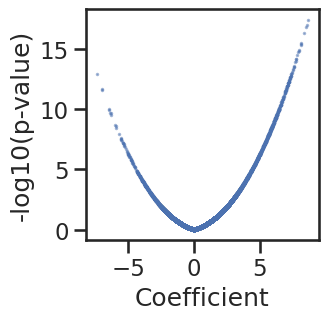

In [81]:
plt.figure(figsize=(3,3))
plt.scatter(res.IBD_coef, -np.log10(res.IBD_pval), s=1, alpha=0.5)
plt.ylabel('-log10(p-value)')
plt.xlabel('Coefficient')
print((sig_res.IBD_coef>0).mean())

In [83]:
sig_res[sig_res.IBD_coef>0]

,tested_index,IBD_pval,IBD_coef,chr,pos,Islands_Name,Relation_to_Island,UCSC_RefGene_Group,UCSC_RefGene_Name,UCSC_RefGene_Accession,GencodeV41_Group,GencodeV41_Name,GencodeV41_Accession
epi_site,,,,,,,,,,,,,
cg00061629_TC21,2358,6.636799e-09,5.799866,chr11,44303708.0,chr11:44303325-44303537;chr11:44305690-4430638...,Shore,NaN,NaN,NaN,NaN,NaN,NaN
cg00097436_BC21,3709,4.514309e-07,5.045883,chr3,141865977.0,NaN,OpenSea,NaN,NaN,NaN,TSS1500,ENSG00000228398.3,ENST00000486956.1
cg00099742_BC21,3796,1.929163e-15,7.945816,chr21,45662698.0,NaN,OpenSea,NaN,NaN,NaN,NaN,NaN,NaN
cg00163611_TC21,6080,2.828743e-13,7.302307,chr12,58543205.0,NaN,OpenSea,NaN,NaN,NaN,TSS1500,ENSG00000258231.5,ENST00000546977.5
cg00218840_TC21,8086,5.734120e-10,6.197571,chr1,228651596.0,chr1:228646195-228648421;chr1:228650239-228650457,Shore,exon_2,DUSP5P1,NR_002834.1_2,TSS1500,ENSG00000206878.1,ENST00000384151.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
nv-GRCh38-chr19-10489330-10489330-C-A_BC11,936676,3.831316e-12,6.943268,chr19,10489330.0,chr19:10491604-10492202,Shelf,exon_5;exon_5,KEAP1;KEAP1,NM_012289.4;NM_203500.2,exon_5;exon_5;exon_1;exon_2,KEAP1;KEAP1;KEAP1;KEAP1,ENST00000171111.10;ENST00000393623.6;ENST00000...
nv-GRCh38-chr3-10149886-10149886-T-C_BC11,936797,5.910310e-08,5.421494,chr3,10149886.0,NaN,OpenSea,exon_3;3UTR;exon_3;exon_2,VHL;VHL;VHL;VHL,NM_000551.4;NM_001354723.2;NM_001354723.2;NM_1...,exon_4;exon_3;exon_4;exon_2;exon_3;exon_3;3UTR...,VHL;VHL;VHL;VHL;VHL;VHL;VHL;VHL,ENST00000696153.1;ENST00000256474.3;ENST000006...
nv-GRCh38-chr4-152328349-152328349-G-C_TC11,936893,1.287336e-07,5.280640,chr4,152328349.0,NaN,OpenSea,exon_8;exon_11;exon_8;exon_9,FBXW7;FBXW7;FBXW7;FBXW7,NM_001013415.2;NM_001349798.2;NM_018315.5;NM_0...,exon_8;exon_8;exon_9;exon_11;exon_1;exon_7;exo...,FBXW7;FBXW7;FBXW7;FBXW7;FBXW7;FBXW7;FBXW7;FBXW7,ENST00000393956.9;ENST00000296555.11;ENST00000...


In [51]:
gene_set = []
for elem in x.UCSC_RefGene_Name:
    gene_set.extend(elem.split(';'))
gene_set = set([elem.strip() for elem in gene_set if elem.strip()])

In [55]:
print(sorted(gene_set))

['AIM2', 'AKR1C4', 'AKT1', 'ANKRD33B', 'ANP32AP1', 'ASPG', 'BCL2L14', 'CACNA1F', 'CARMIL1', 'CCDC148', 'CCDC22', 'CCN2', 'CD19', 'CDHR5', 'CDK8', 'CIC', 'COX7B', 'CYHR1', 'DDOST', 'DUSP5P1', 'ERICH2', 'ERICH2-DT', 'FAM162B', 'FAR2', 'FBXW7', 'FRRS1L', 'GCNT1', 'H3C11', 'HAS3', 'HRAS', 'HSPA5', 'IFIT5', 'IL20RA', 'KEAP1', 'KIFC2', 'KMT2C', 'KRAS', 'KRTAP9-8', 'LEMD1-AS1', 'LIMK2', 'LINC00304', 'LINC00348', 'LINC00350', 'LINC00537', 'LINC00824', 'LINC01003', 'LINC01054', 'LINC01098', 'LINC01162', 'LINC02619', 'LOC100506790', 'LOC102723373', 'LOC283028', 'LYPD6B', 'MAP2K1', 'MAP2K6', 'MEIS3', 'MGMT', 'MIR572', 'MIR622', 'MPHOSPH10P1', 'MPZ', 'MTUS1', 'NCOR1', 'NIPSNAP1', 'NOTCH1', 'NREP', 'OSBPL3', 'PHF24', 'PKNOX2-DT', 'PKP4', 'POLR3G', 'PRKAR1A', 'PRSS44P', 'PTPN5', 'PURG', 'RBFA', 'REEP3', 'RFLNB', 'RPA2', 'RTL8C', 'SFXN4', 'SIRT2', 'SLC17A1', 'SMAD4', 'SMARCA5', 'SNORD114-26', 'SNORD114-27', 'SNORD115-1', 'SNORD89', 'SPATA31C2', 'SRSF4', 'TAS2R19', 'TIMM17B', 'TMEM108-AS1', 'TMEM132D-

In [84]:
chrom_sizes_hg38 = {'chr1': 248956422, 'chr2': 242193529, 'chr3': 198295559, 'chr4': 190214555, 
                    'chr5': 181538259, 'chr6': 170805979, 'chr7': 159345973, 'chr8': 145138636, 
                    'chr9': 138394717, 'chr10': 133797422, 'chr11': 135086622, 'chr12': 133275309, 
                    'chr13': 114364328, 'chr14': 107043718, 'chr15': 101991189, 'chr16': 90338345, 
                    'chr17': 83257441, 'chr18': 80373285, 'chr19': 58617616, 'chr20': 64444167, 
                    'chr21': 46709983, 'chr22': 50818468, 'chrX': 156040895, 'chrY': 57227415}

In [91]:
chr_order = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 
             'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX', 'chrY']
chrom_genomWide_start_index = np.array([0] + [chrom_sizes_hg38[elem] for elem in chr_order[:-1]]).cumsum()
chrom_genomWide_start_index = {elem: chrom_genomWide_start_index[i] for i, elem in enumerate(chr_order)}

In [ ]:
res_annot = res[res.chr.notnull()].copy()

In [131]:
res_sig_annot = res_annot[res_annot.IBD_pval < 0.05/len(res_annot)].copy()
res_sig_annot_wGene = res_sig_annot[res_sig_annot.UCSC_RefGene_Name.notnull()][['chr', 'pos', 'IBD_pval', 'UCSC_RefGene_Name']].copy()
res_sig_annot_wGene['UCSC_RefGene_Name'] = res_sig_annot_wGene['UCSC_RefGene_Name'].apply(lambda x: ';'.join(list(set(x.split(';')))))
res_sig_annot_wGene = res_sig_annot_wGene[res_sig_annot_wGene.UCSC_RefGene_Name.apply(lambda x: 'LOC' not in x and 'LINC' not in x and ';' not in x)].copy()
res_sig_annot_wGene['genome_position'] = res_sig_annot_wGene.apply(lambda x: chrom_genomWide_start_index[x.chr] + x.pos, axis=1)
res_sig_annot_wGene

,chr,pos,IBD_pval,UCSC_RefGene_Name,genome_position
epi_site,,,,,
cg00218840_TC21,chr1,228651596.0,5.734120e-10,DUSP5P1,2.286516e+08
cg00266865_TC11,chr22,29581960.0,7.822113e-09,NIPSNAP1,2.853765e+09
cg00699337_TC21,chr12,12070362.0,9.063105e-09,BCL2L14,1.955838e+09
cg00929606_TC21,chr7,100082657.0,2.041098e-12,ZNF3,1.332087e+09
cg01281000_TC21,chr1,27916134.0,1.344180e-13,RPA2,2.791613e+07
...,...,...,...,...,...
nv-GRCh38-chr3-10149805-10149805-G-A_BC11,chr3,10149805.0,8.677242e-08,VHL,5.012998e+08
nv-GRCh38-chr3-10149886-10149886-T-C_BC11,chr3,10149886.0,5.910310e-08,VHL,5.012998e+08
nv-GRCh38-chr4-152328349-152328349-G-C_TC11,chr4,152328349.0,1.287336e-07,FBXW7,8.417739e+08


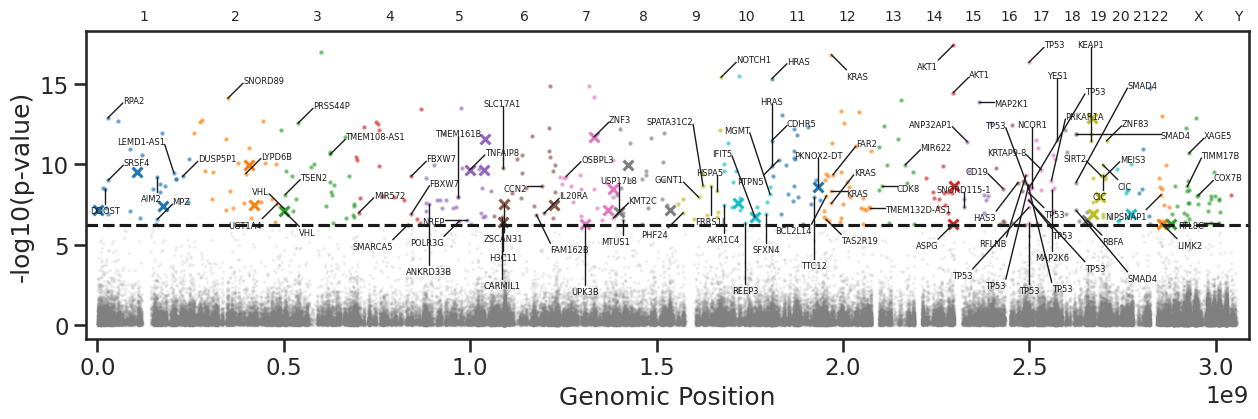

In [136]:
plt.figure(figsize=(15, 4))
cpalette = sns.color_palette("tab10", n_colors=len(chr_order))
for i, ch in enumerate(chr_order):
    ch_df = res_annot[res_annot.chr==ch].copy()
    ch_df_sig_IBD = ch_df[(ch_df.IBD_pval < 0.05/len(res_annot)) & (ch_df.IBD_coef > 0)].copy()
    ch_df_sig_HC = ch_df[(ch_df.IBD_pval < 0.05/len(res_annot)) & (ch_df.IBD_coef < 0)].copy()
    ch_df_notSig = ch_df[ch_df.IBD_pval >= 0.05/len(res_annot)].copy()
    plt.scatter(ch_df_sig_IBD.pos + chrom_genomWide_start_index[ch], -np.log10(ch_df_sig_IBD.IBD_pval), 
                s=3, label=ch, color=cpalette[i], marker='o', alpha=0.5)
    plt.scatter(ch_df_sig_HC.pos + chrom_genomWide_start_index[ch], -np.log10(ch_df_sig_HC.IBD_pval), 
                s=50, label=ch, color=cpalette[i], marker='x')
    plt.scatter(ch_df_notSig.pos + chrom_genomWide_start_index[ch], -np.log10(ch_df_notSig.IBD_pval), 
                s=1, color='gray', alpha=0.1, label=ch)
plt.axhline(-np.log10(0.05/len(res)), color='k', linestyle='--')
plt.xlim(-3e7, chrom_genomWide_start_index[chr_order[-1]] + chrom_sizes_hg38[chr_order[-1]])
plt.xlabel('Genomic Position')
plt.ylabel('-log10(p-value)')
ylim = plt.ylim()
for i, ch in enumerate(chr_order):
    plt.text(chrom_genomWide_start_index[ch] + chrom_sizes_hg38[ch]/2, ylim[1]+0.5, ch[3:], ha='center', va='bottom', fontsize=10)

ax = plt.gca()
text_list = res_sig_annot_wGene['UCSC_RefGene_Name'].values
x = res_sig_annot_wGene['genome_position'].values
y = -np.log10(res_sig_annot_wGene['IBD_pval'].values)
ta.allocate(ax, x, y, text_list, x_scatter=x, y_scatter=y, textsize=6, linecolor='k');

In [93]:
res

,tested_index,IBD_pval,IBD_coef,chr,pos,Islands_Name,Relation_to_Island,UCSC_RefGene_Group,UCSC_RefGene_Name,UCSC_RefGene_Accession,GencodeV41_Group,GencodeV41_Name,GencodeV41_Accession
epi_site,,,,,,,,,,,,,
cg00000776_TC21,20,7.713145e-02,1.767578,chr4,155467053.0,NaN,OpenSea,NaN,NaN,NaN,NaN,NaN,NaN
cg00001476_TC21,39,6.016787e-01,-0.521988,chr20,17399504.0,NaN,OpenSea,NaN,NaN,NaN,NaN,NaN,NaN
cg00002033_TC11,66,6.249508e-01,-0.488846,chr19,39307841.0,chr19:39307146-39308610,Island,exon_5,LRFN1,NM_020862.2,exon_5,LRFN1,ENST00000248668.5
cg00002033_TC12,67,6.545731e-01,-0.447418,chr19,39307841.0,chr19:39307146-39308610,Island,exon_5,LRFN1,NM_020862.2,exon_5,LRFN1,ENST00000248668.5
cg00002190_TC21,75,8.079729e-01,-0.243042,chr8,19697522.0,NaN,OpenSea,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
nv-GRCh38-chr7-140753348-140753348-C-A_BC11,936935,1.224550e-02,2.504990,chr7,140753348.0,NaN,OpenSea,exon_15;exon_16;exon_16;exon_15;exon_15;exon_1...,BRAF;BRAF;BRAF;BRAF;BRAF;BRAF;BRAF;BRAF;BRAF;B...,NM_001354609.2;NM_001374244.1;NM_001374258.1;N...,exon_15;exon_16;exon_14;exon_15;exon_15;exon_1...,BRAF;BRAF;BRAF;BRAF;BRAF;BRAF;BRAF;BRAF;BRAF;B...,ENST00000496384.7;ENST00000644969.2;ENST000006...
nv-GRCh38-chr7-152265113-152265113-C-A_BC11,936950,1.380456e-01,1.483109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nv-GRCh38-chr7-55174015-55174015-G-A_TO11,936964,3.134199e-01,-1.008072,chr7,55174015.0,NaN,OpenSea,exon_17;exon_18;exon_17;exon_18;exon_12;exon_18,EGFR;EGFR;EGFR;EGFR;EGFR;EGFR,NM_001346897.2;NM_001346898.2;NM_001346899.2;N...,exon_18;exon_17;exon_18;exon_5,EGFR;EGFR;EGFR;EGFR,ENST00000275493.7;ENST00000455089.5;ENST000004...


In [5]:
manifest1 = pd.read_excel('/broad/smillie-data/proj/CDSA/epigenetics/India_site/O681123_GSAssayQC_DrVineetAhuja_48S_17Jul2023_Batch1.xls')
manifest2 = pd.read_excel('/broad/smillie-data/proj/CDSA/epigenetics/India_site/Assay QC_OID-681123_Dr Vineet Ahuja_72s_20.07.2023_Batch2.xls')
manifest3 = pd.read_excel('/broad/smillie-data/proj/CDSA/epigenetics/India_site/O681123_GSAssayQC_40S_DrVineetAhuja_18Nov2023_Batch3.xls')
manifest4 = pd.read_excel('/broad/smillie-data/proj/CDSA/epigenetics/India_site/O681123_GSAssayQC_16S_DrVineetAhuja_29Feb2024_Batch4.xls')
manifest5 = pd.read_excel('/broad/smillie-data/proj/CDSA/epigenetics/India_site/O681123_GSAssayQC_23S_Dr. Vineet Ahuja,26Aug,2024_5.xls')
manifest = pd.concat([manifest1, manifest2, manifest3, manifest4, manifest5], ignore_index=True).reset_index(drop=True)

In [13]:
manifest

,S. No,Sample ID,Sample Name,Index,Sample ID.1,Sample Group,Sentrix Barcode,Sample Section,Detected CpG (0.01),Detected CpG (0.05),...,Signal P05 RED,Signal P25 GRN,Signal P25 RED,Signal P50 GRN,Signal P50 RED,Signal P75 GRN,Signal P75 RED,Signal P95 GRN,Signal P95 RED,Array Location
0,1,8008361,PD001,1.0,207222490112_R01C01,207222490112_R01C01,207222490112,R01C01,936269,936592,...,440,971,1382,5006,3187,9181,8867,13537,17635,NaN
1,2,8008362,PD002,2.0,207222490112_R02C01,207222490112_R02C01,207222490112,R02C01,936408,936703,...,469,1079,1429,5569,3247,9928,9089,14480,18149,NaN
2,3,8008363,PD003,3.0,207222490112_R03C01,207222490112_R03C01,207222490112,R03C01,936367,936662,...,513,1127,1334,4983,2980,9668,8742,14943,18816,NaN
3,4,8008364,PD004,4.0,207222490112_R04C01,207222490112_R04C01,207222490112,R04C01,936665,936816,...,626,1339,1600,6427,3410,11607,9939,16858,19804,NaN
4,5,8008365,PD005,5.0,207222490112_R05C01,207222490112_R05C01,207222490112,R05C01,936448,936679,...,650,1529,1733,6713,3820,11929,9930,17546,19908,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,19,8589730,HD066,NaN,NaN,NaN,208369630015,R03C01,935979,936254,...,350,626,906,3503,2075,7288,6269,12304,15377,208369630015_R03C01
185,20,8589731,HD067,NaN,NaN,NaN,208369630015,R04C01,936079,936376,...,380,708,1062,3911,2503,8067,7533,13357,17803,208369630015_R04C01
186,21,8589732,HD068,NaN,NaN,NaN,208369630015,R05C01,935699,936293,...,400,641,1014,3480,2358,7723,7340,13728,18874,208369630015_R05C01
187,22,8589733,HD069,NaN,NaN,NaN,208369630015,R06C01,935585,936024,...,445,736,1200,3973,2843,8599,8646,14781,21031,208369630015_R06C01


In [7]:
manifest_subject2epi = manifest[['Sample Name', 'Sentrix Barcode', 'Sample Section']].copy()
manifest_subject2epi['epi_sampleID'] = manifest_subject2epi['Sentrix Barcode'].astype(str) + '_' + manifest_subject2epi['Sample Section'].astype(str)
manifest_subject2epi.drop(columns=['Sentrix Barcode', 'Sample Section'], inplace=True)
manifest_subject2epi.to_csv('/broad/smillie-data/proj/CDSA/epigenetics/India_site/manifest_subject2epi.csv', index=False)